In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [7]:
from google.colab import files

uploaded = files.upload()

Saving Customer_Purchase_Data (1).csv to Customer_Purchase_Data (1).csv


In [ ]:
from google.colab import files
import io

In [9]:
uploaded = files.upload()

Saving Customer_Purchase_Data (1).csv to Customer_Purchase_Data (1) (1).csv


In [12]:
df = pd.read_csv("Customer_Purchase_Data (1).csv")
df.head()

,Number,Age,Income,Spending_Score,Membership_Years,Purchase_Frequency,Last_Purchase_Amount
0,1,56,61350.84215,12372.864450,15,77.685590,6232.122440
1,2,46,53777.18224,11001.604230,10,51.858351,5545.849698
2,3,32,39460.32263,8007.385018,19,98.166371,4054.645293
3,4,60,66672.12210,13526.548370,12,62.530976,6815.544393
4,5,38,44459.08553,9059.304083,9,46.470533,4617.833484


In [14]:
df['Purchased'] = df['Last_Purchase_Amount'].apply(lambda x: 1 if x > 500 else 0)

In [16]:
X = df[['Age', 'Income', 'Spending_Score', 'Membership_Years', 'Purchase_Frequency']]
y = df['Purchased']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.model_selection import train_test_split

X = df[['Age', 'Income', 'Spending_Score', 'Membership_Years', 'Last_Purchase_Amount']]
y = df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
# Remove missing values
df = df.dropna()

# Double check
print(df.isnull().sum())

Number                  0
Age                     0
Income                  0
Spending_Score          0
Membership_Years        0
Purchase_Frequency      0
Last_Purchase_Amount    0
Purchased               0
dtype: int64


In [29]:
print(df.dtypes)

Number                    int64
Age                       int64
Income                  float64
Spending_Score          float64
Membership_Years          int64
Purchase_Frequency      float64
Last_Purchase_Amount    float64
Purchased                 int64
dtype: object


In [31]:
# Create target using median (guaranteed 2 classes)
threshold = df['Last_Purchase_Amount'].median()

df['Purchased'] = (df['Last_Purchase_Amount'] > threshold).astype(int)

# CHECK (VERY IMPORTANT)
print(df['Purchased'].value_counts())

Purchased
1    681
0    681
Name: count, dtype: int64


In [32]:
import pandas as pd

df['Purchased'] = pd.qcut(df['Last_Purchase_Amount'], q=2, labels=[0,1])
df['Purchased'] = df['Purchased'].astype(int)

print(df['Purchased'].value_counts())

Purchased
1    681
0    681
Name: count, dtype: int64


In [33]:
from sklearn.model_selection import train_test_split

X = df[['Age', 'Income', 'Spending_Score', 'Membership_Years', 'Last_Purchase_Amount']]
y = df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [34]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [35]:
y_pred = model.predict(X_test)

In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[137   0]
 [  0 136]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       137
           1       1.00      1.00      1.00       136

    accuracy                           1.00       273
   macro avg       1.00      1.00      1.00       273
weighted avg       1.00      1.00      1.00       273



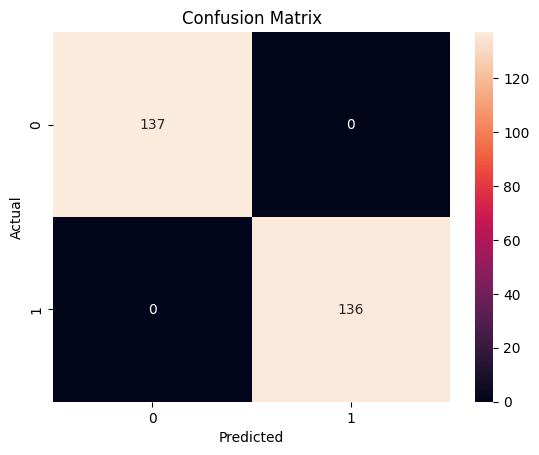

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [38]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 1.0


In [39]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Logistic Regression Accuracy: 1.0
Decision Tree Accuracy: 1.0
